# Understanding Natural Language Processing & Regex Library Practice

In [ ]:
!pip install nltk


In [ ]:
import nltk
nltk.download()

NLTK Downloader
---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> d

Download which package (l=list; x=cancel)?
  Identifier> punkt


      Unzipping tokenizers/punkt.zip.



---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> d

Download which package (l=list; x=cancel)?
  Identifier> stopwords


      Unzipping corpora/stopwords.zip.



---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> d

Download which package (l=list; x=cancel)?
  Identifier> wordnet



---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> words
Command 'words' unrecognized

---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> 1
Command '1' unrecognized

---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> q


True

# N Gram
An N-gram is a contiguous sequence of "N" items from a given text or speech, where "N" is a positive integer

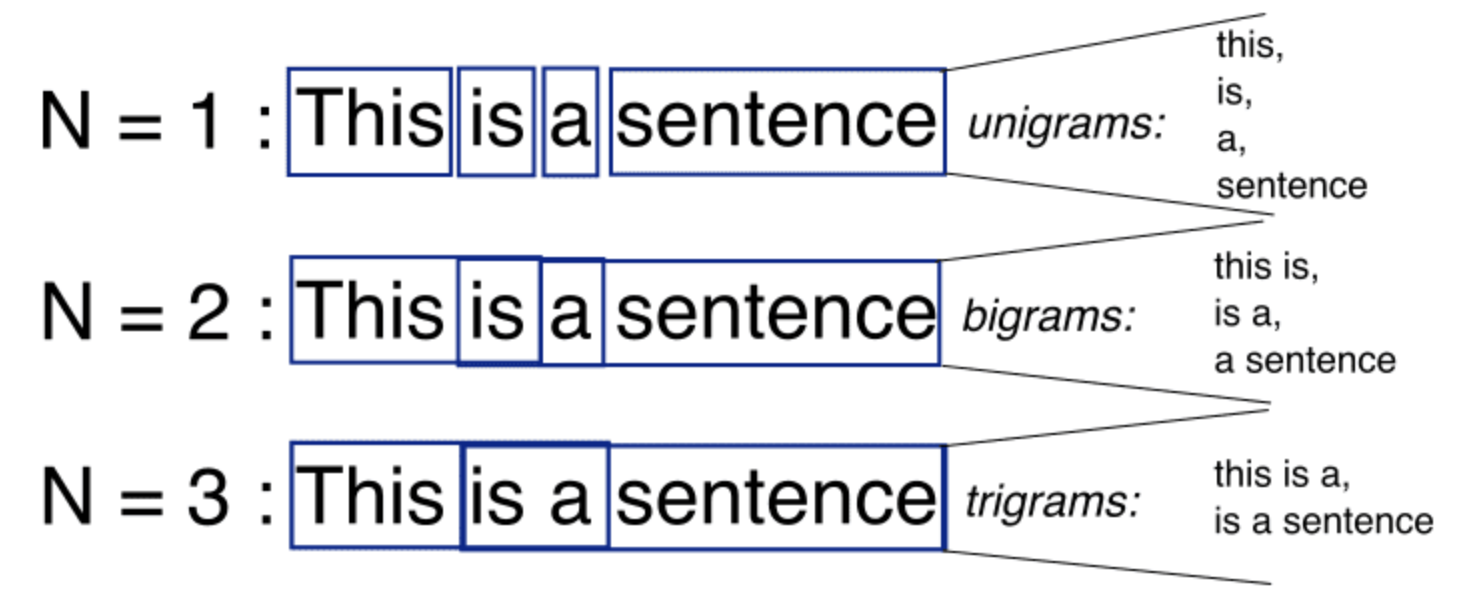

In [ ]:
from collections import defaultdict
import random

In [ ]:
sentences = [
    "I love Machine Learning",
    "I am learning Natural language processing",
    "Machine Learning is fun",
    "I enjoy Machine Learning",
    "Cats are cute",
    "Dogs are loyal",
    "I have a dog",
    "Cats and dogs are friends",
    "I enjoy playing with cats",
    "Dogs love to fetch",
    "I prefer cats over dogs",
    "Cats make great companions",
    "Dogs are man's best friend",

]

In [ ]:
# Function to generate n-grams from sentences
def generate_ngrams(sentences, n):
    ngrams = defaultdict(list)  # empty  dictionary , keys values pairs
    for sentence in sentences:
        words = sentence.lower().split()   # pre-processing (lower the sentence beacuse it will count capital C in unique word )
        for i in range(len(words) - n + 1):
            ngram = ' '.join(words[i:i+n-1])
            next_word = words[i+n-1]
            ngrams[ngram].append(next_word)
    return ngrams

In [ ]:
ngram_2 = generate_ngrams(sentences, 2)
ngram_3 = generate_ngrams(sentences, 3)
ngram_4 = generate_ngrams(sentences, 4)

In [ ]:
ngram_2

defaultdict(list,
            {'i': ['love', 'am', 'enjoy', 'have', 'enjoy', 'prefer'],
             'love': ['machine', 'to'],
             'machine': ['learning', 'learning', 'learning'],
             'am': ['learning'],
             'learning': ['natural', 'is'],
             'natural': ['language'],
             'language': ['processing'],
             'is': ['fun'],
             'enjoy': ['machine', 'playing'],
             'cats': ['are', 'and', 'over', 'make'],
             'are': ['cute', 'loyal', 'friends', "man's"],
             'dogs': ['are', 'are', 'love', 'are'],
             'have': ['a'],
             'a': ['dog'],
             'and': ['dogs'],
             'playing': ['with'],
             'with': ['cats'],
             'to': ['fetch'],
             'prefer': ['cats'],
             'over': ['dogs'],
             'make': ['great'],
             'great': ['companions'],
             "man's": ['best'],
             'best': ['friend']})

In [ ]:
# Predict the next word based on 2-gram
seed_2 = random.choice(list(ngram_2.keys()))
next_word_2 = random.choice(ngram_2[seed_2])

In [ ]:
print("Using 2-gram model:")
print(f"Seed: '{seed_2}', Predicted Next Word: '{next_word_2}'")

Using 2-gram model:
Seed: 'prefer', Predicted Next Word: 'cats'


In [ ]:
# Predict the next word based on 3-gram
seed_3 = random.choice(list(ngram_3.keys()))
next_word_3 = random.choice(ngram_3[seed_3])

In [ ]:
print("Using 3-gram model:")
print(f"Seed: '{seed_3}', Predicted Next Word: '{next_word_3}'")

Using 3-gram model:
Seed: 'and dogs', Predicted Next Word: 'are'


Make dictionay like that write frequency of the words and pick the word
'are': ['adorable', 'loyal', 'friends', "man's"], 'dogs': ['are', 'are', 'love', 'are'], 'have': ['a'], 'a': ['dog'], 'and': ['dogs'], 'enjoy': ['playing'], 'playing': ['with'], 'with': ['cats'], 'to': ['fetch'], 'prefer': ['cats'], 'over': ['dogs'], 'make': ['great'], 'great': ['companions'], "man's": ['best'], 'best': ['friend']})

In [ ]:
from collections import Counter

In [ ]:
word_dict = {
    'are': ['adorable', 'loyal', 'friends', "man's"],
    'dogs': ['are', 'are', 'love', 'are'],
    'have': ['a'],
    'a': ['dog'],
    'and': ['dogs'],
    'enjoy': ['playing'],
    'playing': ['with'],
    'with': ['cats'],
    'to': ['fetch'],
    'prefer': ['cats'],
    'over': ['dogs'],
    'make': ['great'],
    'great': ['companions'],
    "man's": ['best'],
    'best': ['friend']
}

In [ ]:
def build_frequency_dict(word_dict):
    """
    Convert a dictionary of words and their following words into a frequency dictionary.

    Args:
        word_dict (dict): Example:
            {'dogs': ['are', 'are', 'love', 'are']}

    Returns:
        dict: Frequency dictionary:
            {'dogs': {'are': 3, 'love': 1}}
    """
    freq_dict = {}
    for word, next_words in word_dict.items():
        freq_dict[word] = dict(Counter(next_words))
    return freq_dict

In [ ]:
# Convert to frequency dictionary
freq_dict = build_frequency_dict(word_dict)

In [ ]:
# Print result
for k, v in freq_dict.items():
    print(f"{k}: {v}")

are: {'adorable': 1, 'loyal': 1, 'friends': 1, "man's": 1}
dogs: {'are': 3, 'love': 1}
have: {'a': 1}
a: {'dog': 1}
and: {'dogs': 1}
enjoy: {'playing': 1}
playing: {'with': 1}
with: {'cats': 1}
to: {'fetch': 1}
prefer: {'cats': 1}
over: {'dogs': 1}
make: {'great': 1}
great: {'companions': 1}
man's: {'best': 1}
best: {'friend': 1}


##Noise Removal
Any piece of text which is not relevant to the context of the data and the end-output can be specified as the noise.

For example
- language stopwords (commonly used words of a language – is, am, the, of, in etc),
- URLs or links, social media entities (mentions, hashtags), punctuations and industry specific words.

This step deals with removal of all types of noisy entities present in the text.

In [ ]:
noise_list = ["is", "a", "this", "and","the", "in", "..."]  # these are the noise words that i define in the list


# function for removing the noise words from the text or sentences.
def remove_noise(input_text):
    words = input_text.split()
    noise_free_words = [word for word in words if word not in noise_list]
    noise_free_text = " ".join(noise_free_words)
    return noise_free_text

In [ ]:
sentences = "I like the machine learning and doing work in this field."
print(remove_noise(sentences))

I like machine learning doing work field.


# Regular Expression
Regular expressions use two types of characters:

- Meta characters: As the name suggests, these characters have a special meaning, similar to * in wild card.

- Literals (like a,b,1,2…)

## Regex

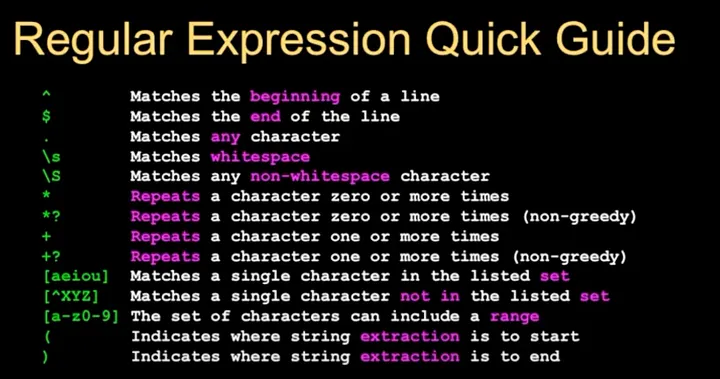

In [ ]:
import re

# Method of Regular Expression
## re.match

This method finds match if it occurs at start of the string.

In [ ]:
result = re.match(r'AV', 'AV Analytics Vidhya AV')
print(result)
result_2 = re.match(r'Analytics', 'AV Analytics Vidhya AV')
print(result_2)

<re.Match object; span=(0, 2), match='AV'>
None


for the first AV it is showing that it is available but for the Analytics it is returning None because Analytics is not the starting word.

## re.search(pattern, string)
It is similar to match() but it doesn’t restrict us to find matches at the beginning of the string only.

In [ ]:
result = re.search(r'Analytics', 'AV Analytics Vidhya AV')
print(result)

<re.Match object; span=(3, 12), match='Analytics'>


## re.findall (pattern, string)
It helps to get a list of all matching patterns. It has no constraints of searching from start or end.

In [ ]:
result = re.findall(r'AV', 'AV Analytics Vidhya AV')
print(result)

['AV', 'AV']


## re.split(pattern, string, [maxsplit=0])
This methods helps to split string by the occurrences of given pattern.

In [ ]:
result=re.split(r'y','Analytics')
result

['Anal', 'tics']

## re.sub(pattern, repl, string):
It helps to search a pattern and replace with a new sub string. If the pattern is not found, string is returned unchanged.

In [ ]:
result=re.sub(r'Pakistan','the World','AV is largest Analytics community of Pakistan')
result

'AV is largest Analytics community of the World'

# Extract each character

In [ ]:
text = "Myself Ahmed Islam. I am working as an AI engineer At IR Solutions."

result=re.findall(r'.',text)
print(result)

['M', 'y', 's', 'e', 'l', 'f', ' ', 'A', 'h', 'm', 'e', 'd', ' ', 'I', 's', 'l', 'a', 'm', '.', ' ', 'I', ' ', 'a', 'm', ' ', 'w', 'o', 'r', 'k', 'i', 'n', 'g', ' ', 'a', 's', ' ', 'a', 'n', ' ', 'A', 'I', ' ', 'e', 'n', 'g', 'i', 'n', 'e', 'e', 'r', ' ', 'A', 't', ' ', 'I', 'R', ' ', 'S', 'o', 'l', 'u', 't', 'i', 'o', 'n', 's', '.']


. is capturing the space also so avoiding the space we use \w

In [ ]:
result=re.findall(r'\w',text)
print(result)

['M', 'y', 's', 'e', 'l', 'f', 'A', 'h', 'm', 'e', 'd', 'I', 's', 'l', 'a', 'm', 'I', 'a', 'm', 'w', 'o', 'r', 'k', 'i', 'n', 'g', 'a', 's', 'a', 'n', 'A', 'I', 'e', 'n', 'g', 'i', 'n', 'e', 'e', 'r', 'A', 't', 'I', 'R', 'S', 'o', 'l', 'u', 't', 'i', 'o', 'n', 's']


# Extract each word (using “*” or “+“)

In [ ]:
result = re.findall(r'\w*', text)
result

['Myself',
 '',
 'Ahmed',
 '',
 'Islam',
 '',
 '',
 'I',
 '',
 'am',
 '',
 'working',
 '',
 'as',
 '',
 'an',
 '',
 'AI',
 '',
 'engineer',
 '',
 'At',
 '',
 'IR',
 '',
 'Solutions',
 '',
 '']

In [ ]:
result = re.findall(r'\w+', text)
result

['Myself',
 'Ahmed',
 'Islam',
 'I',
 'am',
 'working',
 'as',
 'an',
 'AI',
 'engineer',
 'At',
 'IR',
 'Solutions']

# Extract each word (using “^“)

In [ ]:
# for the first word
result=re.findall(r'^\w+', text)
print(result)

['Myself']


# Extract all characters after “@”

In [ ]:
# all character after @
result=re.findall(r'@\w+','abc.test@gmail.com, xyz@test.in, test.first@analyticsvidhya.com, first.test@rest.biz')
print(result)

['@gmail', '@test', '@analyticsvidhya', '@rest']


In [ ]:
# .com, .in part are not extracted so let me extract it also

result=re.findall(r'@\w+.\w+','abc.test@gmail.com, xyz@test.in, test.first@analyticsvidhya.com, first.test@rest.biz')
print(result)

['@gmail.com', '@test.in', '@analyticsvidhya.com', '@rest.biz']


# Return date from given string

In [ ]:
result=re.findall(r'\d{2}-\d{2}-\d{4}','Amit 34-3456 12-05-2007, XYZ 56-4532 11-11-2011, ABC 67-8945 12-01-2009')
print(result)

['12-05-2007', '11-11-2011', '12-01-2009']


In [ ]:
# for stripping hashtag in text file

sentence = "Just #check out this link: www.amazingpics.com. It has amazing photos!"

# a regex matching the hashtag pattern
regex = r"#\w+"

# Replace the regex with an empty string by re.sub()
no_hashtag = re.sub(regex, "", sentence)

In [ ]:
no_hashtag

'Just  out this link: www.amazingpics.com. It has amazing photos!'

In [ ]:
# Usage code for .

my_links = "Just check out this link: www.amazingpics.com. It has amazing photos!"
re.findall(r"www.+com", my_links)
# For unknown characters in the specific, we can use ".+"

['www.amazingpics.com']